
Running Euler Forward for h = 0.1 ...
Max absolute error for h = 0.1: nan


<ipython-input-1-80cc596d1c31>:7: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-1-80cc596d1c31>:16: RuntimeWarning: invalid value encountered in double_scalars
  y[n+1] = y[n] + h * f(t[n], y[n])


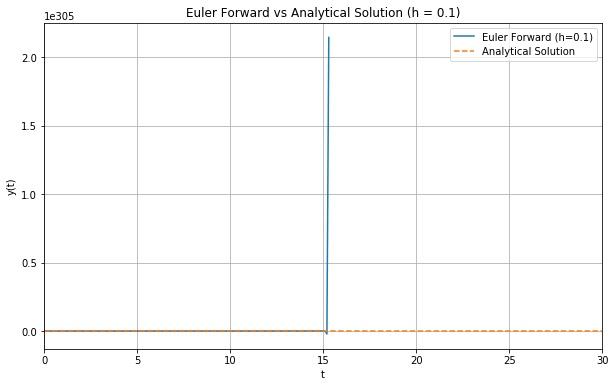


Running Euler Forward for h = 0.01 ...
Max absolute error for h = 0.01: nan


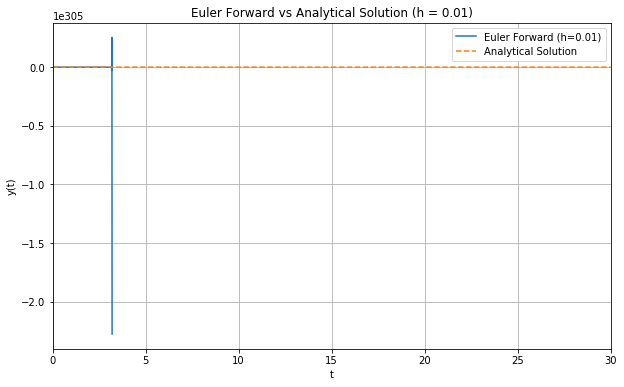


Running Euler Forward for h = 0.001 ...
Max absolute error for h = 0.001: 3.671427e-01


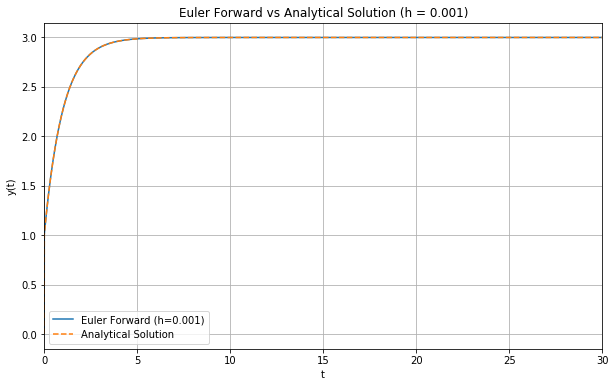


Running Euler Forward for h = 1e-05 ...


In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

#differential equation: y' = -1000y + 3000 - 2000e^(-t), y(0)=0
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)
def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)
def euler_forward(h, t0=0, tf=30, y0=0):
    N = int((tf - t0) / h)
    t = np.linspace(t0, t0 + N*h, N + 1)
    y = np.zeros(N + 1)
    y[0] = y0    
    for n in range(N):
        y[n+1] = y[n] + h * f(t[n], y[n])    
    return t, y

#step sizes
h_values = [0.1, 0.01, 0.001, 0.00001, 0.0000001]

for h in h_values:
    print(f"\nRunning Euler Forward for h = {h} ...")
    t_euler, y_euler = euler_forward(h)
    y_true = y_exact(t_euler)
    max_error = np.max(np.abs(y_true - y_euler))
    print(f"Max absolute error for h = {h}: {max_error:.6e}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_euler, y_euler, label=f"Euler Forward (h={h})")
    plt.plot(t_euler, y_true, '--', label="Analytical Solution")
    plt.xlim(0, 30)
    plt.xlabel("t")
    plt.ylabel("y(t)")
    plt.title(f"Euler Forward vs Analytical Solution (h = {h})")
    plt.legend()
    plt.grid(True)
    plt.show()